In [4]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy

from numpy.random import choice


In [160]:
def probability(tomorrow,today):
    if (today==0) & (tomorrow==0): return 0.5
    elif (today==0) & (tomorrow==1): return 0.5
    elif (today==1) & (tomorrow==0): return 0.1
    elif (today==1) & (tomorrow==1): return 0.9

#today cloudy, tomorrow cloudy: 0,0
#today cloudy, tomorrow clear: 1,0

def jump(today):
    if (today==0):
        draw = choice([0,1],1,p=[probability(0,today),probability(1,today)],replace=False)
        
    else: 
        draw = choice([0,1],1,p=[probability(0,today),probability(1,today)],replace=False)

    return draw[0]
def jump(today):
    if (today==0):
        draw = choice([0,1],1,p=[0.5,0.5],replace=False)
        
    elif (today==1): 
        draw = choice([0,1],1,p=[0.1,0.9],replace=False)

    return draw[0]

In [161]:
#devo fare in modo che a ogni estrazione le probabilità siano rispettate: non può essere deterministico
(jump(0))

1

In [223]:
N=20000
p_init = 0
p_current = p_init
posterior = [p_current]
clear_counter=[p_init]


for i in range(N):
    p_current = jump(p_current)
    posterior = np.append(posterior,p_current)
    clear_counter = np.append(clear_counter,posterior.sum())


In [228]:
burn_in = 12000


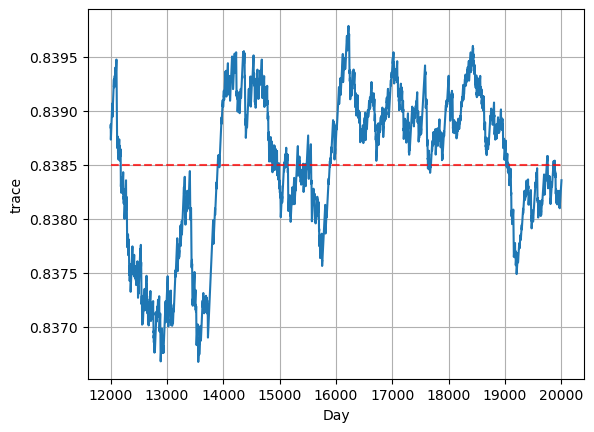

In [229]:
plt.plot(np.arange(1,N+2)[burn_in:],clear_counter[burn_in:]/np.arange(1,N+2)[burn_in:])
plt.xlabel('Day')
plt.ylabel('trace')
plt.hlines(0.8385,burn_in,N,linestyle='--',alpha=0.75,color='r')
plt.grid()